In [17]:
# code by ALEXANDRE CAZALS; slightly modified by RK

<h3>Exercise 6.1 Boston housing prices

This exercise has two objectives. On the one hand, we try to estimate house prices in Boston based on house price data. On the other hand, we consider the ethical problems associated with the data and its use in machine learning.

We proceed as follows: 

1. We visualise the data: plot a distribution of the housing prices, a correlation heatmap on the features, and a scatter plot.

2. We try to estimate housing prices with one feature, the number of rooms. 

3. We try to estimate housing prices with two features, the number of rooms and some other varianle. 

4. We compare several methods with all the features. You can choose the methods from LinearRegression, Lasso, ElasticNet, KNeighborsRegressor, DecisionTreeRegressor, SVR, AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor, and ExtraTreesRegressor or try all of them.


In [1]:
import numpy as np
import matplotlib.pyplot as plt 

import pandas as pd  
import seaborn as sns 


In [2]:
boston = pd.read_csv('boston.csv')
boston = boston.iloc[:, 1:]
boston.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6


Above, the variables are: per capita crime rate by town; proportion of residential land zoned for lots over 25,000 sq.ft.; proportion of non-retail business acres per town; Charles River dummy variable (= 1 if tract bounds river; 0 otherwise); nitric oxides concentration (parts per 10 million); average number of rooms per dwelling; proportion of owner-occupied units built prior to 1940; weighted distances to five Boston employment centres; index of accessibility to radial highways; full-value property-tax rate per 10,000 dollar;  pupil-teacher ratio by town; lower status of the population; Median value of owner-occupied homes in 1000's dollar. 

As mentioned in the exercise paper, this is an example of machine learning data that raises serious ethical issues.

<h4>1. Visualization: 3 pictures

1. Draw a distribution of housing average prices 'MEDV' using distplot by seaborn.

/tmp/ipykernel_7892/2735400690.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston['MEDV'])


<Axes: xlabel='MEDV', ylabel='Density'>

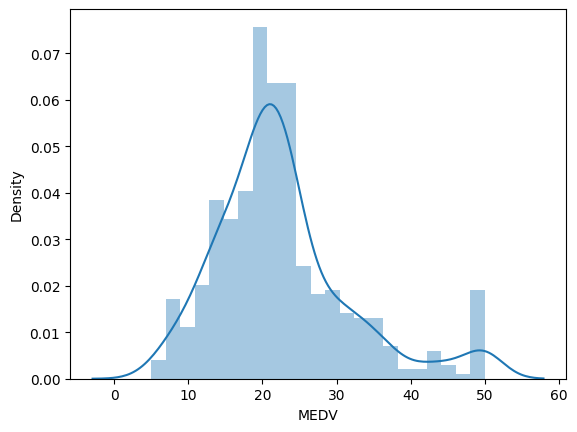

In [4]:
# draw a distirbution of MEDV
sns.distplot(boston['MEDV'])

2. Draw a correlation heatmap matrix as done in previous exericies. 

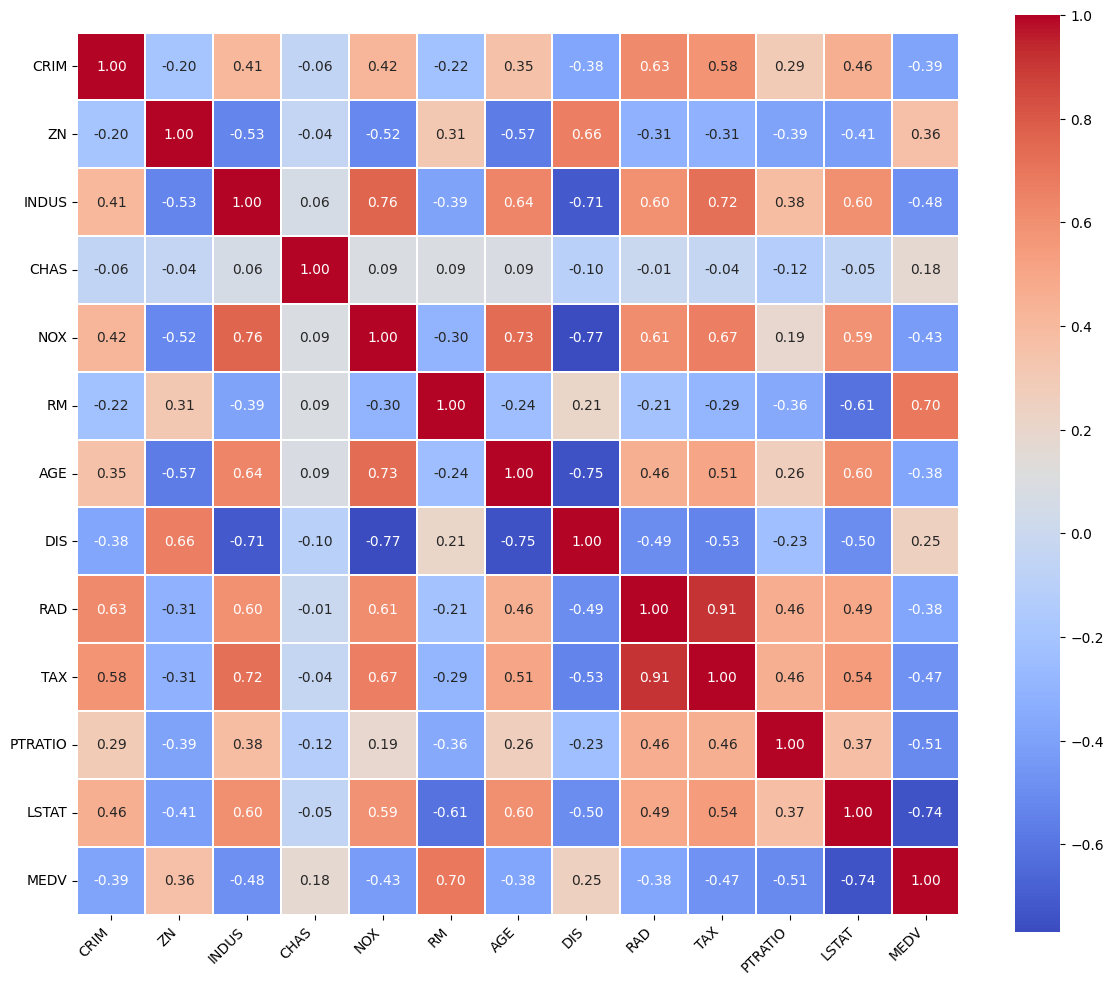

In [8]:
# correlation heatmap
# Create correlation heatmap with annotations
plt.figure(figsize=(12, 10))  # Increase figure size for better readability
sns.heatmap(
    boston.corr(),     # Correlation matrix
    annot=True,        # Show correlation values
    cmap='coolwarm',   # Use cool-warm color scheme
    fmt='.2f',         # Round to 2 decimal places
    square=True,       # Make cells square
    linewidths=0.3     # Add grid lines between cells
)

# Rotate x-axis labels for better fit
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Display the plot
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

3. Draw a two scatterplots where x is 'RM' (number of rooms) or 'TAX' (full-value property-tax rate per 10,000 dollars) and y is 'MEDV'

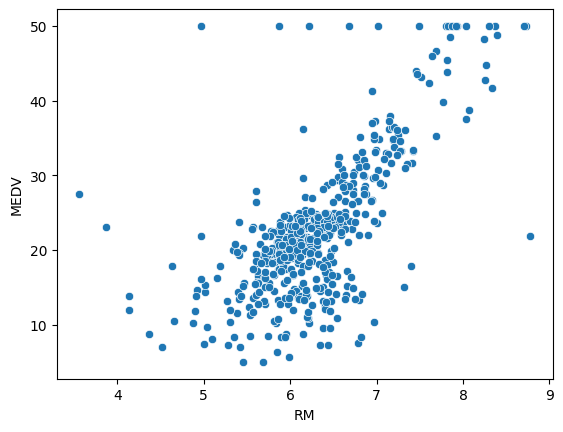

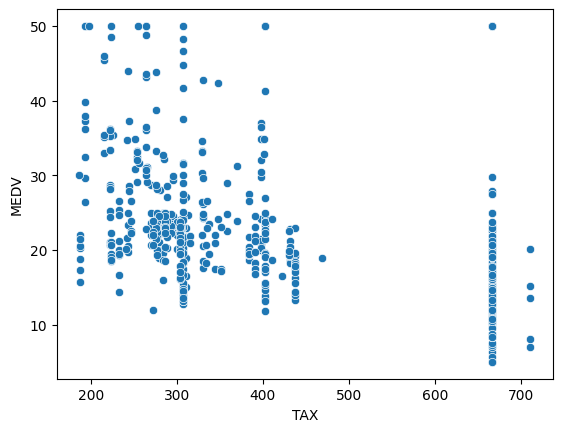

In [9]:
# scatter plot here
sns.scatterplot(x='RM', y='MEDV', data=boston)
plt.show()
sns.scatterplot(x='TAX', y='MEDV', data=boston)
plt.show()

Q: How would you analyse the results? Are 'TAX' and 'RM' good choises in our regression problem?

<h4>Linear regression with one variable

Let us estimate the apartment price using one feature: the number of rooms RM.

In [10]:
X_rooms = boston['RM']
y_price = boston['MEDV']

X_rooms = np.array(X_rooms).reshape(-1,1)
y_price = np.array(y_price).reshape(-1,1)


Import train_test_set from sklearn.model_selection. Using it, split the data to train data (0.8) and test data (0.2).

In [11]:
#import train data 
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_rooms, y_price, test_size=0.2, random_state=0)


Apply linear regression and compute the r2 score and the mean-squared error. 



In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("mse: ", mse)
print("r2: ", r2)


mse:  46.90735162739531
r2:  0.42394386816456286


Next, choose two features, one of your choice xx and the number of rooms RM. Repeat the procedure: linear regression, R2, MSE. 

In [17]:
X_two=boston[['TAX','RM']]
Y = boston['MEDV']

X_train, X_test, Y_train, Y_test = train_test_split(X_two, Y, test_size=0.2, random_state=0)


In [18]:
model = LinearRegression()
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("mse: ", mse)
print("r2: ", r2)

mse:  49.82929853411734
r2:  0.38806025133014377


<h4>4. Comparing regression using all the features

Next, we use all the 13 features to estimate housing prices. Let X be the original bostob data set  with the first 12 columns (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO,  LSTA). Let Y be the last column 'MEDV' of original data set.  

In [19]:
X = boston.drop('MEDV', axis=1)
Y = boston['MEDV']


Use MinMaxScaler from sklearn.preprocessing to scale X so that for each variable, mean=0 and sdt=1. 
Q: Why do we need to do this?

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler().fit(X)
scaled_X = scaler.transform(X)


We split the data to train and test set as done earlier. 

In [21]:
test_size = 0.20

X_train, X_test, Y_train, Y_test = train_test_split(scaled_X, Y, test_size = test_size, random_state = None)


In [22]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

We organize the different regression models in a dictionary and do a 10-fold cross validation for each model. 

In [23]:

# user variables to tune
folds   = 20
metric  = "neg_mean_squared_error"

# hold different regression models in a single dictionary
models = {}
models["Linear"]        = LinearRegression()
models["Lasso"]         = Lasso()
models["ElasticNet"]    = ElasticNet()
models["KNN"]           = KNeighborsRegressor()
models["DecisionTree"]  = DecisionTreeRegressor()
models["SVR"]           = SVR()
models["AdaBoost"]      = AdaBoostRegressor()
models["GradientBoost"] = GradientBoostingRegressor()
models["RandomForest"]  = RandomForestRegressor()
models["ExtraTrees"]    = ExtraTreesRegressor()



We do the 10-fold cross validation using a loop, the model dictionary, KFold, and cross_val_score. Each result is added to model_results and each model_name to model_names. Within the loop, we can  printthe model_name, the mean of the result and the standard deviation of the result. 

Please note that this is one way to do the regressions. You can also do it in your own way.f 

In [27]:
# 10-fold cross validation for each model
model_results = []
model_names   = []
for model_name in models:
    kfold = KFold(n_splits=folds, random_state=None)
    cv_results = cross_val_score(models[model_name], X_train, Y_train, cv=kfold, scoring=metric)
    model_results.append(cv_results)
    model_names.append(model_name)
    msg = "%s: %f (%f)" % (model_name, cv_results.mean(), cv_results.std())
    print(msg)
    model_results
    

Linear: -21.938414 (8.469344)
Lasso: -64.228011 (28.924753)
ElasticNet: -70.571167 (30.254079)
KNN: -25.201207 (15.213808)
DecisionTree: -26.449395 (21.579421)
SVR: -31.218738 (18.165993)
AdaBoost: -15.108169 (11.141214)
GradientBoost: -10.223691 (7.657743)
RandomForest: -13.359544 (11.229815)
ExtraTrees: -9.067984 (6.662285)


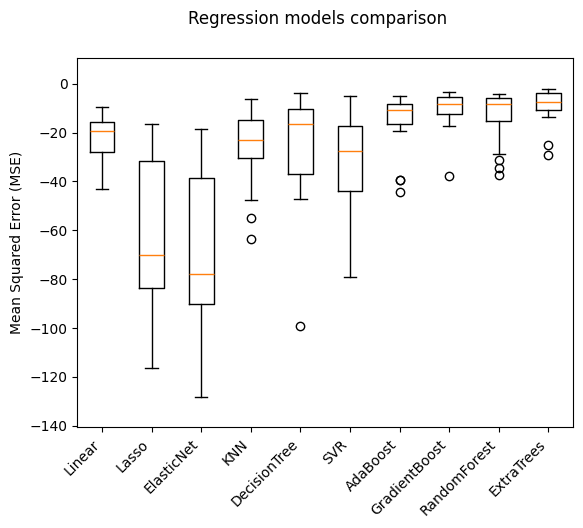

In [25]:
# box-whisker plot to compare regression models
figure = plt.figure()
figure.suptitle('Regression models comparison')
axis = figure.add_subplot(111)
plt.boxplot(model_results)
axis.set_xticklabels(model_names, rotation = 45, ha="right")
axis.set_ylabel("Mean Squared Error (MSE)")
plt.margins(0.05, 0.1)

Q: analyse the results. What are the best performing regression models? Why? How about the standard deviations? 
Compare also the results of Linear, Lasso and ElasticNet? Was this expected?

To finish this exercise, compute the feature importances of X using RandomForestRegressor.feature_importances_ 
Remember that with this kind of data set, the results of machine learning can lead to distorted images and discrimination. 

In [26]:
# feature importance here
model = RandomForestRegressor()
model.fit(X_train, Y_train)

feature_importances = pd.DataFrame(model.feature_importances_, index=X.columns, columns=['importance'])
feature_importances = feature_importances.sort_values('importance', ascending=False)
feature_importances


,importance
RM,0.528757
LSTAT,0.292736
DIS,0.046782
CRIM,0.035973
NOX,0.025030
PTRATIO,0.021636
TAX,0.018170
AGE,0.014220
INDUS,0.007577
RAD,0.006088


The correct images and regression approximations are in a separate response paper.